# PH Trend

In [63]:
import sys
from pathlib import Path

# Make sure the project root (Codes/) is importable so we can `import config.*`
_root = Path.cwd()
if not (_root / "config").is_dir() and (_root.parent / "config").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap

from config.eez import getEEZ
from config.regions import resolve_region_settings
from config.spatial import subset_to_bbox

## Define User Input

In [ ]:
# -------------------------
# USER CONFIG (pick one)
# -------------------------
REGION = "FJI"  # options: "PACIFIC", "ASM", "COK", "FJI", "FSM", "GUM", "KIR", "MHL", "MNP", "NCL", "NIU", "NRU", "PCN", "PLW", "PNG", "PYF", "SLB", "TKL", "TON", "TUV", "VUT", "WLF", "WSM"


# FOOTER TEXT
TEXT_LEFT = "Nauru Meteorological Service (NMS) 2026"
TEXT_RIGHT = "Copernicus"
PLOT_TITLE = "Satellite pH Trends (1982–2024) — Pacific"

# Pull bbox + EEZ layer path from the shared config package
bbox, eez_zip_path = resolve_region_settings(REGION)

## Read NetCDF

In [65]:
# -------------------------
# Read NetCDF
# -------------------------
ds = Dataset("https://ocean-thredds01.spc.int/thredds/dodsC/POP/PCC/ph_trend_data.nc", "r")
ph = ds.variables["ph_trend"][:]
lat = ds.variables["latitude"][:]
lon = ds.variables["longitude"][:]


## Subsetting and Data Selection

In [66]:
# Replace fill values with masked values
fill_value = getattr(ds.variables["ph_trend"], "_FillValue", None)
if fill_value is not None:
    ph = np.ma.masked_where(ph == fill_value, ph)

# Convert longitude from 0-360 to -180..180
lon = np.where(lon > 180, lon - 360, lon)

# Sort longitudes and reorder accordingly
lon_sort = np.argsort(lon)
lon = lon[lon_sort]
ph = ph[:, lon_sort] * 10  # year-1 → decade-1

# Wrap lon to 0..360 for plotting/subsetting in Pacific-centered convention
lon_wrapped = np.where(lon < 0, lon + 360, lon)

# Sort wrapped longitudes and reorder accordingly
wrap_sort = np.argsort(lon_wrapped)
lon_wrapped = lon_wrapped[wrap_sort]
ph = ph[:, wrap_sort]

# Subset to selected bbox
lon2d, lat2d, ph_sub = subset_to_bbox(lat, lon_wrapped, ph, bbox)

# Levels / colormap
levels = np.arange(-0.052, -0.0037, 0.0005)
cmap = plt.get_cmap("RdBu_r")
norm = BoundaryNorm(levels, cmap.N)

# Evenly spaced major ticks + no minor ticks
major_ticks = np.linspace(levels[0], levels[-1], 8)

## Plot

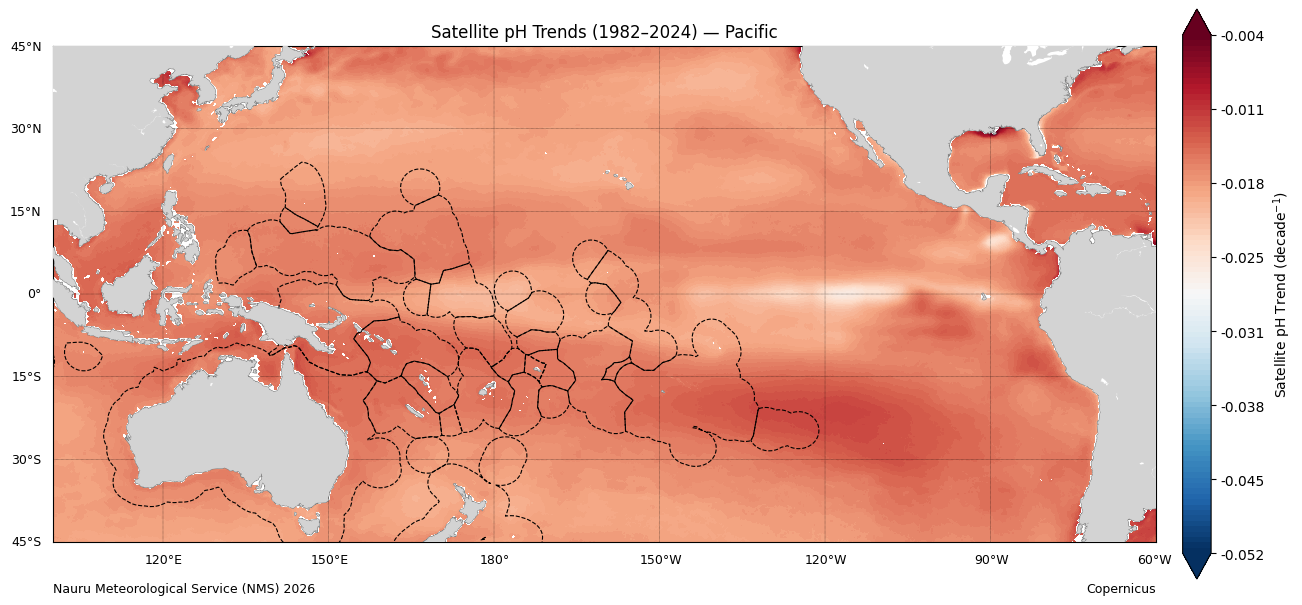

In [67]:
# -------------------------
# Plot
# -------------------------
fig = plt.figure(figsize=(14, 6))
ax = plt.gca()

m = Basemap(
    projection="cyl",
    llcrnrlon=bbox["west"],
    urcrnrlon=bbox["east"],
    llcrnrlat=bbox["south"],
    urcrnrlat=bbox["north"],
    resolution="l",
    ax=ax,
 )

cf = m.contourf(
    lon2d, lat2d, ph_sub,
    levels=levels, cmap=cmap, norm=norm,
    extend="both", latlon=True
)

m.drawcoastlines(color="grey", linewidth=0.8)
m.fillcontinents(color="lightgrey", lake_color="white", zorder=10)

# Gridlines: PACIFIC uses broader spacing; country zoom uses finer spacing
if REGION == "PACIFIC":
    par_step = 15
    mer_step = 30
else:
    par_step = 5
    mer_step = 5

par_start = np.floor(bbox["south"] / par_step) * par_step
par_end   = np.ceil(bbox["north"] / par_step) * par_step
mer_start = np.floor(bbox["west"] / mer_step) * mer_step
mer_end   = np.ceil(bbox["east"] / mer_step) * mer_step

m.drawparallels(np.arange(par_start, par_end + 0.1, par_step),
                labels=[1, 0, 0, 0], fontsize=9, linewidth=0.3, dashes=[1, 1])
m.drawmeridians(np.arange(mer_start, mer_end + 0.1, mer_step),
                labels=[0, 0, 0, 1], fontsize=9, linewidth=0.3, dashes=[1, 1])

cbar = plt.colorbar(cf, pad=0.02, ticks=major_ticks)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
cbar.ax.minorticks_off()
cbar.ax.yaxis.set_minor_locator(mticker.NullLocator())
cbar.ax.tick_params(which="minor", length=0)
cbar.set_label("Satellite pH Trend (decade$^{-1}$)")
plt.title(PLOT_TITLE)

# EEZ on top (last)
getEEZ(ax=ax, m=m, local_path=eez_zip_path, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()

# Put footer relative to the axes (tracks bbox/plot size)
ax.text(0.0, -0.08, TEXT_LEFT,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, color="black", clip_on=False)

ax.text(1.0, -0.08, TEXT_RIGHT,
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="black", clip_on=False)
plt.show()

ds.close()